In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polatory as p
import polatory.three as p3

def variog(m: p3.Model, diff: np.ndarray) -> float:
    v = m.nugget
    for rbf in m.rbfs:
        v += rbf.evaluate(np.zeros(3)) - rbf.evaluate(diff)
    return v

def dip_azimuth(dip: float, dip_az: float) -> np.ndarray:
    dip = np.radians(dip)
    dip_az = np.radians(dip_az)
    return np.array([np.cos(dip) * np.sin(dip_az),
                     np.cos(dip) * np.cos(dip_az),
                     -np.sin(dip)])

In [2]:
data = pd.read_csv("data/sim3d.csv")
points = data[["x", "y", "z"]].values
values = data["sim1"].values
data.describe()

,x,y,z,sim1
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,499.875235,500.812335,498.276604,0.001858
std,288.384770,288.388695,288.817000,1.444090
min,0.013249,0.040722,0.030675,-5.879610
25%,251.786604,250.657596,248.324892,-0.982701
50%,498.470243,501.569797,495.533415,0.003205
75%,749.654017,751.591268,749.014427,0.977377
max,999.974923,999.995387,999.997030,6.134107


In [3]:
calc = p3.VariogramCalculator(lag_distance=5.0, num_lags=200)
calc.directions = p3.DIRECTIONS_46
variogs = calc.calculate(points, values)

In [4]:
cov1 = p3.CovSpherical([1.0, 50.0])
cov2 = p3.CovSpherical([1.0, 100.0])
covs = [cov1, cov2]
m = p3.Model(covs, poly_degree=-1)

best_fit = None
best_cost = float("inf")
for _ in range(10):
    fit = p3.VariogramFitting(variogs, m)
    if fit.final_cost < best_cost:
        best_fit = fit
        best_cost = fit.final_cost

m = best_fit.model
print(m.description)

        Type       Psill       Major  Semi-major       Minor     Dip Az.         Dip    Rotation
         nug      0.1231
         sph      1.0476     50.9162     35.6708     16.4375    314.5112     44.1301     88.0130
         sph      0.9160    149.3058     94.2629     60.9345    314.5112     44.1301     88.0130



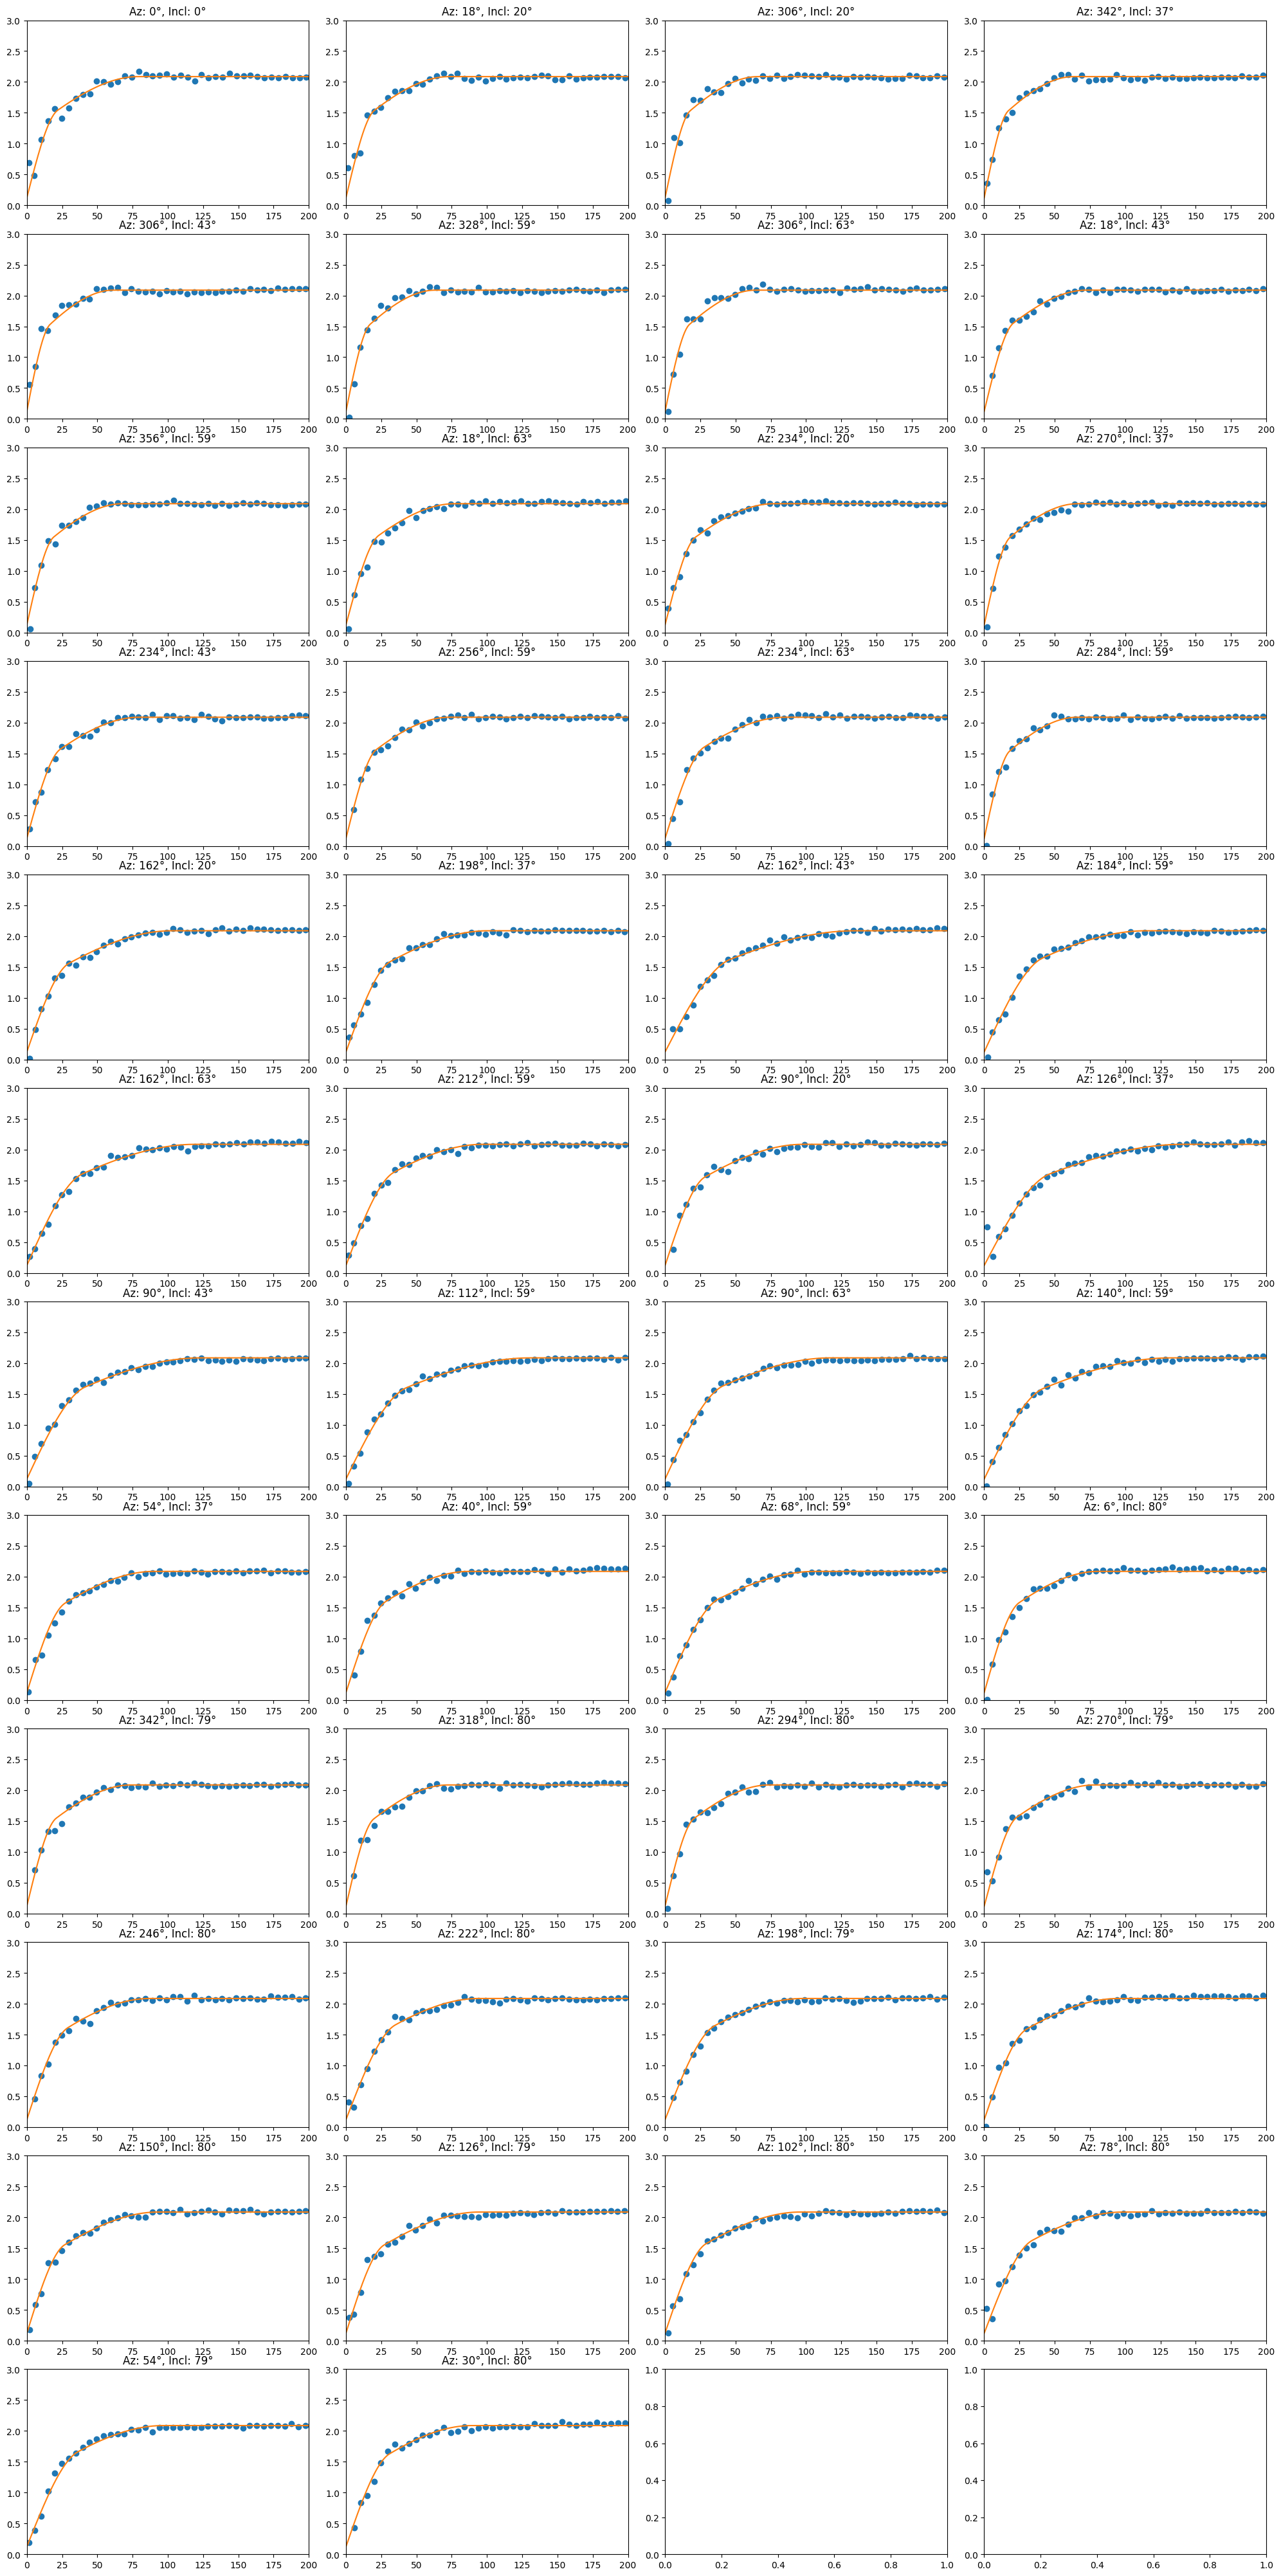

In [5]:
fig, ax = plt.subplots(nrows=12, ncols=4, figsize=(20, 40))
fig.tight_layout()
for i in range(12):
    for j in range(4):
        if 4 * i + j >= len(variogs):
            break
        v = variogs[4 * i + j]
        dir = v.direction
        az = np.degrees(np.arctan2(dir[0], dir[1]))
        if az < 0.0:
            az += 360.0
        incl = np.degrees(np.arccos(dir[2]))
        xs = np.linspace(0.0, 1000.0, 1000)
        ys = np.array([variog(m, x * dir) for x in xs])
        ax[i, j].plot(np.linalg.norm(v.bin_lag, axis=1), v.bin_gamma, "o")
        ax[i, j].plot(xs, ys, "-")
        ax[i, j].set_title(f"Az: {az:.0f}°, Incl: {incl:.0f}°")
        ax[i, j].set_xlim(0.0, 200.0)
        ax[i, j].set_ylim(0.0, 3)
        ax[i, j].margins(0.0)

In [ ]:
inter = p3.Interpolant(m)
inter.fit(points, values, absolute_tolerance=1e-3)

In [ ]:
fn = p.RbfFieldFunction(inter)
bbox = p3.Bbox.from_points(points)
iso = p.Isosurface(bbox, resolution=5.0)
surf = iso.generate(fn, isovalue=-1.0)
surf.export_obj("data/iso.obj")